In [60]:
# Task 1.
# Текстурные характеристики:
#  - Реализуйте подсчет гистограммы 
#  - Реализуйте рассчет текстурных характеристик Laws 
#  - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM
# Для каждого случая: выполните тренировку классификатора (knn, svm, trees)
# Решите задачу сегментации данных на основе классификации изображений каждым методом.
# Выполните ручную разметку изображений на регионы.
# Сравните результат полученной классификации и размеченной.

In [61]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import entropy, skew, kurtosis
from skimage.feature import graycomatrix, graycoprops
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import warnings

In [62]:
DATA_FOLDER = "./KTH_TIPS"
TEST_IMAGE_PATH = "./test_image.png"
BIN_COUNT = 256
IMAGE_RESIZE_SHAPE = (128, 128)
NUM_IMAGES_PER_TEXTURE = 50
TEST_SIZE = 0.25
RANDOM_STATE = 42
KNN_NEIGHBORS = 3
DECISION_TREE_MAX_DEPTH = 10
DEFAULT_WINDOW_SIZE = 32
NUM_CLASSES = 4
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_LEVELS = 32
LAWS_KERNELS = [
    ([1,4,6,4,1], 'L'),     
    ([-1,-2,0,2,1], 'E'),   
    ([-1,0,2,0,-1], 'S'),   
    ([-1,2,0,-2,1], 'W'),   
    ([1,-4,6,-4,1], 'R')    
]

In [63]:
def compute_histogram_features(image, bins):
    histogram = cv.calcHist([image], [0], None, [bins], [0, 256])
    histogram = histogram.flatten()
    
    bin_width = 256 / bins
    bin_centers = np.array([i * bin_width + bin_width / 2 for i in range(bins)])
    normalized_histogram = histogram / np.sum(histogram)
    
    weighted_data = np.repeat(bin_centers, histogram.astype(int))
    
    features = {}
    features['mean'] = np.average(bin_centers, weights=histogram)
    features['variance'] = np.var(weighted_data) if len(weighted_data) > 0 else 0
    features['standard_deviation'] = np.std(weighted_data) if len(weighted_data) > 0 else 0
    features['skewness'] = skew(weighted_data) if len(weighted_data) > 0 else 0
    features['kurtosis'] = kurtosis(weighted_data) if len(weighted_data) > 0 else 0
    features['energy'] = np.sum(normalized_histogram**2)
    features['entropy'] = entropy(normalized_histogram)
    features['median'] = np.median(image)
    features['percentile_25'] = np.percentile(image, 25)
    features['percentile_75'] = np.percentile(image, 75)
    features['minimum'] = np.min(image)
    features['maximum'] = np.max(image)
    features['contrast'] = np.max(image) - np.min(image)
    
    return features, normalized_histogram

In [64]:
texture_names = os.listdir(DATA_FOLDER)
first_texture_name = texture_names[0]
first_texture_folder = os.path.join(DATA_FOLDER, first_texture_name)

image_files = [f for f in os.listdir(first_texture_folder)]
example_image_path = os.path.join(first_texture_folder, image_files[10])
example_image = cv.imread(example_image_path, cv.IMREAD_GRAYSCALE)

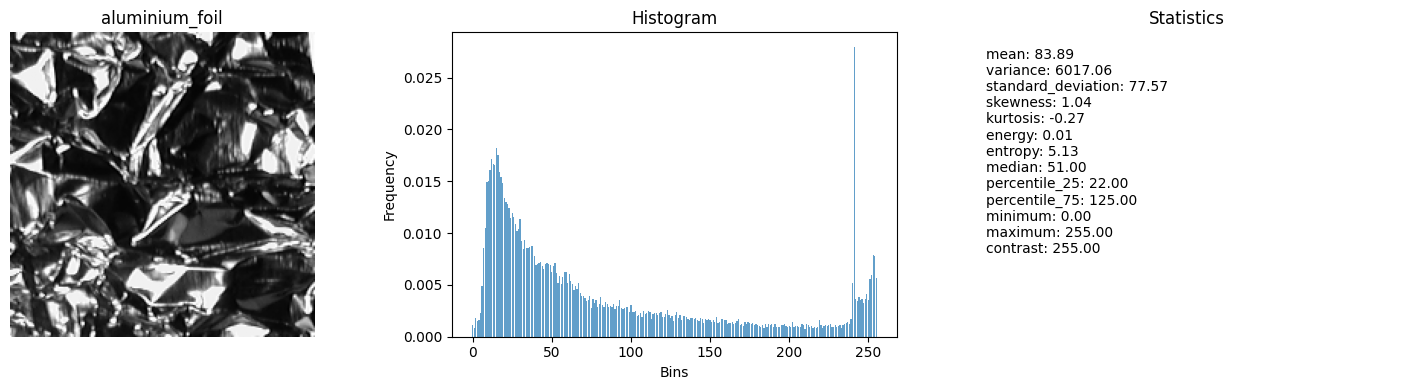

In [65]:
histogram_features, normalized_histogram = compute_histogram_features(example_image, BIN_COUNT)

fig, (image_axis, histogram_axis, stats_axis) = plt.subplots(1, 3, figsize=(15, 4))

image_axis.imshow(example_image, cmap='gray')
image_axis.set_title(first_texture_name)
image_axis.axis('off')

histogram_axis.bar(range(BIN_COUNT), normalized_histogram, alpha=0.7)
histogram_axis.set_title('Histogram')
histogram_axis.set_xlabel('Bins')
histogram_axis.set_ylabel('Frequency')

stats_text = '\n'.join([f'{key}: {value:.2f}' for key, value in histogram_features.items()])
stats_axis.text(0.05, 0.95, stats_text, transform=stats_axis.transAxes, verticalalignment='top')
stats_axis.set_title('Statistics')
stats_axis.axis('off')

plt.tight_layout()
plt.show()

In [66]:
def compute_laws_features(image):
    features_dict = {}
    
    for kernel1, name1 in LAWS_KERNELS:
        for kernel2, name2 in LAWS_KERNELS:
            convolution_kernel = np.outer(kernel1, kernel2)
            filtered_image = cv.filter2D(image.astype(np.float32), -1, convolution_kernel)
            features_dict[f"{name1}{name2}"] = np.mean(filtered_image ** 2)
    
    total_energy = sum(features_dict.values())
    if total_energy > 0:
        for key in features_dict:
            features_dict[key] /= total_energy
    
    return features_dict

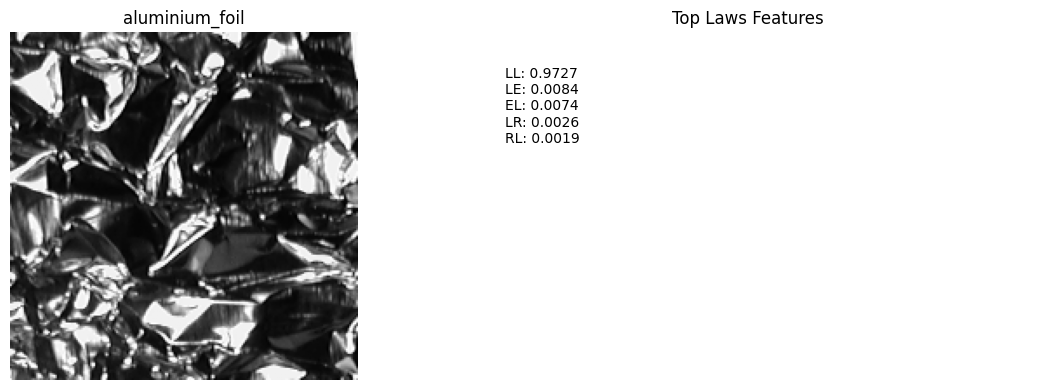

In [67]:
laws_features = compute_laws_features(example_image)

fig, (image_axis, stats_axis) = plt.subplots(1, 2, figsize=(12, 4))

image_axis.imshow(example_image, cmap='gray')
image_axis.set_title(first_texture_name)
image_axis.axis('off')

top_five_features = sorted(laws_features.items(), key=lambda x: x[1], reverse=True)[:5]
features_text = '\n'.join([f'{key}: {value:.4f}' for key, value in top_five_features])

stats_axis.text(0.1, 0.9, features_text, transform=stats_axis.transAxes, verticalalignment='top')
stats_axis.set_title('Top Laws Features')
stats_axis.axis('off')

plt.tight_layout()
plt.show()

In [68]:
def compute_glcm_features(image):
    quantized_image = (image // 8).astype(np.uint8)
    glcm_matrix = graycomatrix(
        quantized_image, 
        distances=GLCM_DISTANCES, 
        angles=GLCM_ANGLES, 
        levels=GLCM_LEVELS, 
        symmetric=True, 
        normed=True
    )
    
    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    features_dict = {}
    
    for prop in properties:
        value = np.mean(graycoprops(glcm_matrix, prop))
        features_dict[prop] = value
    
    return features_dict

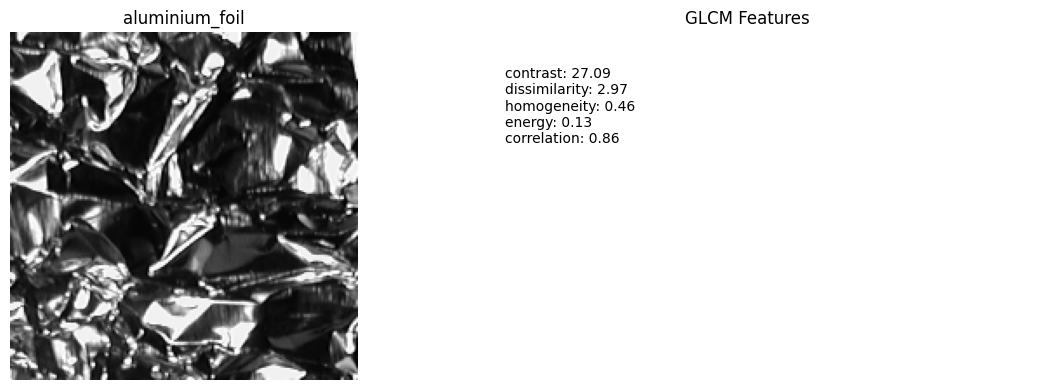

In [69]:
glcm_features = compute_glcm_features(example_image)

fig, (image_axis, stats_axis) = plt.subplots(1, 2, figsize=(12, 4))

image_axis.imshow(example_image, cmap='gray')
image_axis.set_title(first_texture_name)
image_axis.axis('off')

stats_text = '\n'.join([f'{key}: {value:.2f}' for key, value in glcm_features.items()])

stats_axis.text(0.1, 0.9, stats_text, transform=stats_axis.transAxes, verticalalignment='top')
stats_axis.set_title('GLCM Features')
stats_axis.axis('off')

plt.tight_layout()
plt.show()

In [70]:
def prepare_dataset(folder_path, feature_type, num_images_per_texture):
    features_list = []
    labels_list = []
    
    for texture_name in os.listdir(folder_path):
        texture_path = os.path.join(folder_path, texture_name)
        if not os.path.isdir(texture_path):
            continue
        
        for image_file in os.listdir(texture_path)[:num_images_per_texture]:
            full_image_path = os.path.join(texture_path, image_file)
            loaded_image = cv.imread(full_image_path, cv.IMREAD_GRAYSCALE)
            
            if loaded_image is not None:
                resized_image = cv.resize(loaded_image, IMAGE_RESIZE_SHAPE)
                
                if feature_type == 'Histogram':
                    features_dict, _ = compute_histogram_features(resized_image, BIN_COUNT)
                elif feature_type == 'Laws':
                    features_dict = compute_laws_features(resized_image)
                else:  
                    features_dict = compute_glcm_features(resized_image)
                
                features_list.append(list(features_dict.values()))
                labels_list.append(texture_name)
    
    return np.array(features_list), labels_list


def train_classifiers(features, labels):
    encoded_labels = LabelEncoder().fit_transform(labels)
    train_features, test_features, train_labels, test_labels = train_test_split(features, encoded_labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=encoded_labels)
    
    scaler = StandardScaler()
    scaled_train_features = scaler.fit_transform(train_features)
    scaled_test_features = scaler.transform(test_features)
    
    classifiers_dict = {}
    classifiers_dict['KNN'] = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, n_jobs=-1)
    classifiers_dict['SVM'] = SVC(kernel='rbf', random_state=RANDOM_STATE)
    classifiers_dict['DecisionTree'] = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=DECISION_TREE_MAX_DEPTH)
    
    for name in classifiers_dict:
        classifiers_dict[name].fit(scaled_train_features, train_labels)

    return classifiers_dict, scaled_test_features, test_labels, scaler

In [71]:
trained_models_dict = {}

feature_types = ['Histogram', 'Laws', 'GLCM']
for feature_type in feature_types:
    print(f"Training {feature_type}")
    
    features, labels = prepare_dataset(DATA_FOLDER, feature_type, NUM_IMAGES_PER_TEXTURE)
    classifiers, test_features, test_labels, scaler = train_classifiers(features, labels)
    
    trained_models_dict[feature_type] = {
        'classifiers': classifiers, 'scaler': scaler
    }
    
    print(f"  Data shape: {features.shape}")
    for name in classifiers:
        predictions = classifiers[name].predict(test_features)
        accuracy = accuracy_score(test_labels, predictions)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            report = classification_report(test_labels, predictions, output_dict=True, zero_division=0)
            f1_score = report['macro avg']['f1-score']
        
        print(f"  {name}: Accuracy={accuracy:.3f}, F1={f1_score:.3f}")
    print()

Training Histogram
  Data shape: (500, 13)
  KNN: Accuracy=0.872, F1=0.875
  SVM: Accuracy=0.760, F1=0.760
  DecisionTree: Accuracy=0.744, F1=0.743

Training Laws
  Data shape: (500, 25)
  KNN: Accuracy=0.824, F1=0.826
  SVM: Accuracy=0.536, F1=0.520
  DecisionTree: Accuracy=0.688, F1=0.687

Training GLCM
  Data shape: (500, 5)
  KNN: Accuracy=0.704, F1=0.704
  SVM: Accuracy=0.544, F1=0.546
  DecisionTree: Accuracy=0.624, F1=0.630



In [72]:
def perform_texture_segmentation(image_path, trained_models_dict, feature_type, model_name, window_size=DEFAULT_WINDOW_SIZE, step_size=None, num_classes=NUM_CLASSES):
    original_image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    
    if step_size is None:
        step_size = window_size
    
    model_info = trained_models_dict[feature_type]
    scaler = model_info['scaler']
    selected_model = model_info['classifiers'][model_name]
    
    height, width = original_image.shape
    temporary_segmentation_map = np.zeros((height, width), dtype=np.uint8)
    all_predictions = []
    
    if feature_type == 'Histogram':
        feature_func = lambda img: list(compute_histogram_features(img, BIN_COUNT)[0].values())
    elif feature_type == 'Laws':
        feature_func = lambda img: list(compute_laws_features(img).values())
    else:
        feature_func = lambda img: list(compute_glcm_features(img).values())
    
    for y in range(0, height - window_size + 1, step_size):
        for x in range(0, width - window_size + 1, step_size):
            window = original_image[y:y+window_size, x:x+window_size]
            
            features = feature_func(window)
            scaled_features = scaler.transform([features])
            prediction = selected_model.predict(scaled_features)[0]
            
            temporary_segmentation_map[y:y+window_size, x:x+window_size] = prediction
            all_predictions.append(prediction)
    
    unique_classes, class_counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique_classes[np.argsort(class_counts)[-num_classes:]]
    
    final_segmentation_map = np.zeros_like(temporary_segmentation_map)
    
    for new_class_id, old_class_id in enumerate(top_classes):
        final_segmentation_map[temporary_segmentation_map == old_class_id] = new_class_id
    
    not_in_top_mask = ~np.isin(temporary_segmentation_map, top_classes)
    if np.any(not_in_top_mask):
        final_segmentation_map[not_in_top_mask] = 1  
    
    return final_segmentation_map, original_image

In [73]:
def display_segmentation(image_path, trained_models_dict, **kwargs):
    segmentation_map, original_image = perform_texture_segmentation(image_path, trained_models_dict, **kwargs)
    
    fig, (original_axis, segmentation_axis, overlay_axis) = plt.subplots(1, 3, figsize=(12, 4))
    
    original_axis.imshow(original_image, cmap='gray')
    original_axis.set_title('Original Image')
    original_axis.axis('off')
    
    segmentation_axis.imshow(segmentation_map, cmap='tab10')
    segmentation_axis.set_title('Segmentation Map')
    segmentation_axis.axis('off')
    
    overlay_axis.imshow(segmentation_map, cmap='tab10', alpha=0.8)
    overlay_axis.imshow(original_image, cmap='gray', alpha=0.3)
    overlay_axis.set_title('Overlay')
    overlay_axis.axis('off')
    
    plt.tight_layout()
    plt.show()

In [74]:
display_segmentation(TEST_IMAGE_PATH, trained_models_dict, window_size=4, feature_type='Laws', model_name='SVM')
display_segmentation(TEST_IMAGE_PATH, trained_models_dict, window_size=2, feature_type='GLCM', model_name='DecisionTree')

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
p = "./test_image.png"
i = cv.imread(p)
i_rgb = cv.cvtColor(i, cv.COLOR_BGR2RGB)

man_m = man_seg(i_rgb)
man_m = remap(man_m, 4)

error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


NameError: name 'i_rgb' is not defined

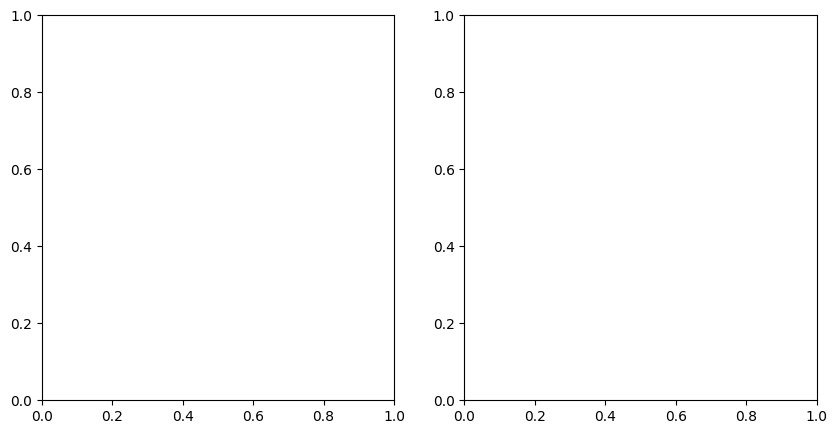

In [ ]:
def perform_manual_segmentation(image_rgb):
    grayscale_image = cv.cvtColor(image_rgb, cv.COLOR_RGB2GRAY)
    _, threshold_mask = cv.threshold(grayscale_image, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    
    contours, _ = cv.findContours(threshold_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(threshold_mask)

    if contours:
        largest_contour = max(contours, key=cv.contourArea)
        cv.drawContours(final_mask, [largest_contour], 0, 1, -1)
    
    return final_mask


def remap_classes(mask, num_classes):
    unique_values, counts = np.unique(mask, return_counts=True)
    top_classes = unique_values[np.argsort(-counts)[:num_classes]]

    remapped_mask = np.zeros_like(mask)
    for new_id, old_id in enumerate(top_classes):
        remapped_mask[mask == old_id] = new_id

    return remapped_mask

In [ ]:
loaded_image = cv.imread(TEST_IMAGE_PATH)
image_rgb = cv.cvtColor(loaded_image, cv.COLOR_BGR2RGB)

manual_mask = perform_manual_segmentation(image_rgb)
manual_mask = remap_classes(manual_mask, NUM_CLASSES)

NameError: name 'image_rgb' is not defined

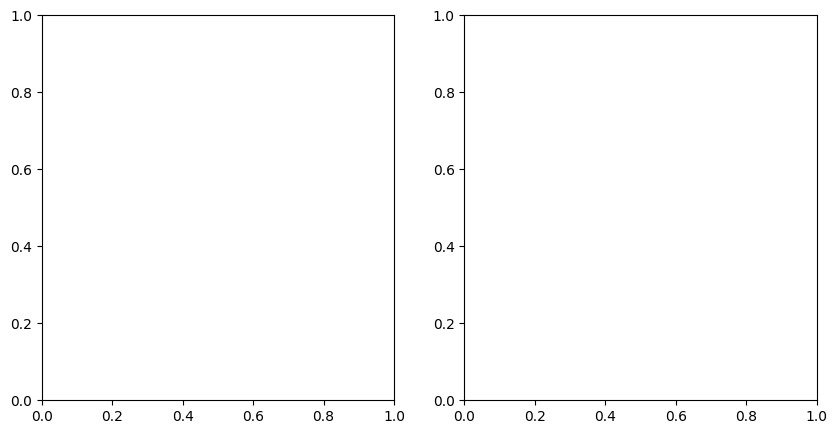

In [ ]:
fig, (original_axis, segmentation_axis) = plt.subplots(1, 2, figsize=(10, 5))

original_axis.imshow(image_rgb)
original_axis.set_title('Original Image')
original_axis.axis('off')

segmentation_axis.imshow(manual_mask, cmap='tab10')
segmentation_axis.set_title('Manual Segmentation')
segmentation_axis.axis('off')

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, jaccard_score
def find_best_class_mapping(true_mask, predicted_mask):
    true_flattened = true_mask.flatten()
    predicted_flattened = predicted_mask.flatten()
    
    true_classes = np.unique(true_flattened)
    predicted_classes = np.unique(predicted_flattened)
    
    class_mapping = {}
    for predicted_class in predicted_classes:
        best_true_class = None
        best_overlap = -1
        
        for true_class in true_classes:
            overlap = np.sum((true_flattened == true_class) & (predicted_flattened == predicted_class))
            if overlap > best_overlap:
                best_overlap = overlap
                best_true_class = true_class
        
        class_mapping[predicted_class] = best_true_class
    
    return class_mapping


def compare_segmentations(manual_mask, predicted_mask, original_image):
    if manual_mask.shape != predicted_mask.shape:
        predicted_mask = cv.resize(predicted_mask, (manual_mask.shape[1], manual_mask.shape[0]))
    
    mapping = find_best_class_mapping(manual_mask, predicted_mask)
    mapped_predicted_mask = np.zeros_like(predicted_mask)
    
    for predicted_class, true_class in mapping.items():
        mapped_predicted_mask[predicted_mask == predicted_class] = true_class
    
    accuracy = accuracy_score(manual_mask.flatten(), mapped_predicted_mask.flatten())
    iou_scores = jaccard_score(manual_mask.flatten(), mapped_predicted_mask.flatten(), 
                               average=None, labels=np.unique(manual_mask))
    
    print(f"Accuracy: {accuracy:.1%}")
    
    print("IoU per class:")
    for index, class_id in enumerate(np.unique(manual_mask)):
        print(f"  Class {class_id}: {iou_scores[index]:.3f}")
    
    fig, (original_axis, manual_axis, predicted_axis) = plt.subplots(1, 3, figsize=(15, 5))
    
    original_axis.imshow(original_image, cmap='gray')
    original_axis.set_title('Original Image')
    original_axis.axis('off')
    
    manual_axis.imshow(manual_mask, cmap='tab10')
    manual_axis.set_title('Manual Mask')
    manual_axis.axis('off')
    
    predicted_axis.imshow(mapped_predicted_mask, cmap='tab10')
    predicted_axis.set_title('Predicted Mask')
    predicted_axis.axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
selected_feature_type = 'GLCM'
selected_model_name = 'DecisionTree'
print(f"{selected_feature_type} - {selected_model_name}\n")

predicted_mask, _ = perform_texture_segmentation(
    TEST_IMAGE_PATH, 
    trained_models_dict,
    window_size=2, 
    feature_type=selected_feature_type, 
    model_name=selected_model_name
)

original_image = cv.imread(TEST_IMAGE_PATH, cv.IMREAD_GRAYSCALE)
compare_segmentations(manual_mask, predicted_mask, original_image)